In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
pk = pd.read_csv('/content/drive/MyDrive/pokemons.csv')

Adding a 'fit' column that analyzes how fit a pokemon is based on its speed and weight:

In [ ]:
for index, row in pk.iterrows():
    pk['fit'] = pk['speed']*pk['weight']

#Top 5 fittest pokemons:

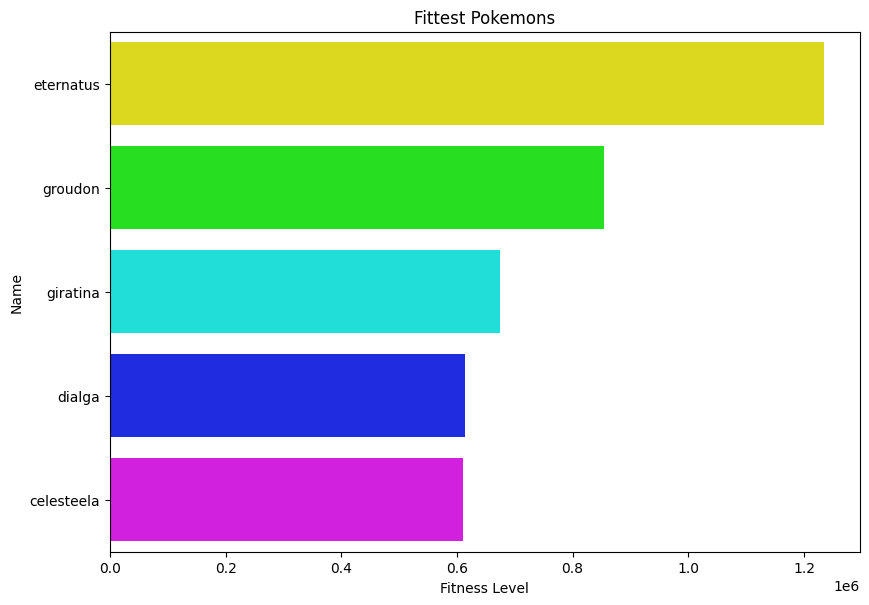

In [ ]:
fittest = pk.nlargest(5, 'fit')

colors = sns.color_palette("hsv", len(fittest))

plt.figure(figsize=(10, 8))

sns.barplot(x='fit', y='name', data=fittest, hue='name', palette=colors, dodge=False, legend=False)

plt.subplots_adjust(left=0.2, right=0.95, top=0.7, bottom=0.05)

plt.xlabel('Fitness Level')
plt.ylabel('Name')
plt.title('Fittest Pokemons')
plt.show()

#Top 5 Weakest Pokemons:

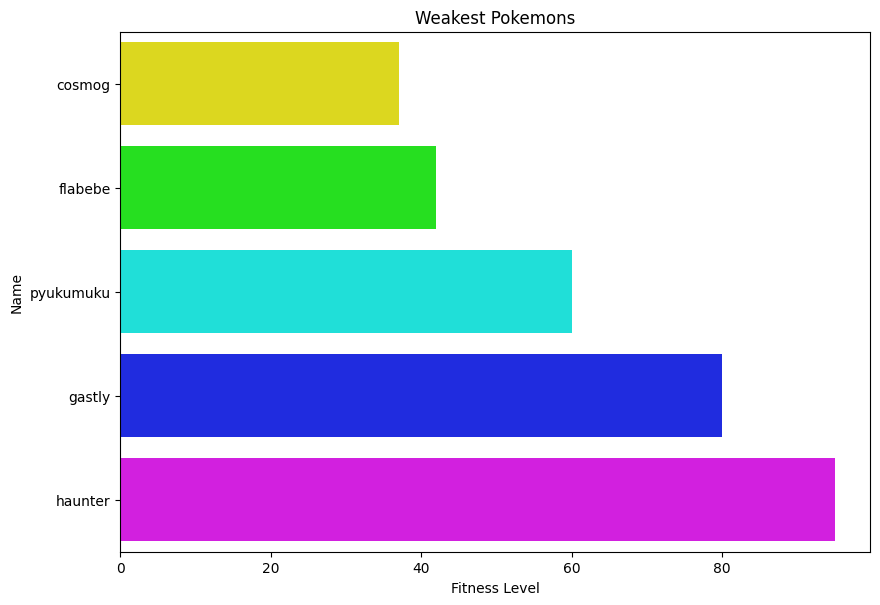

In [ ]:
weakest = pk.nsmallest(5, 'fit')

colors = sns.color_palette("hsv", len(weakest))

plt.figure(figsize=(10, 8))

sns.barplot(x='fit', y='name', data=weakest, hue='name', palette=colors, dodge=False, legend=False)

plt.subplots_adjust(left=0.2, right=0.95, top=0.7, bottom=0.05)

plt.xlabel('Fitness Level')
plt.ylabel('Name')
plt.title('Weakest Pokemons')
plt.show()

#The Fittest Pokemons by Type:

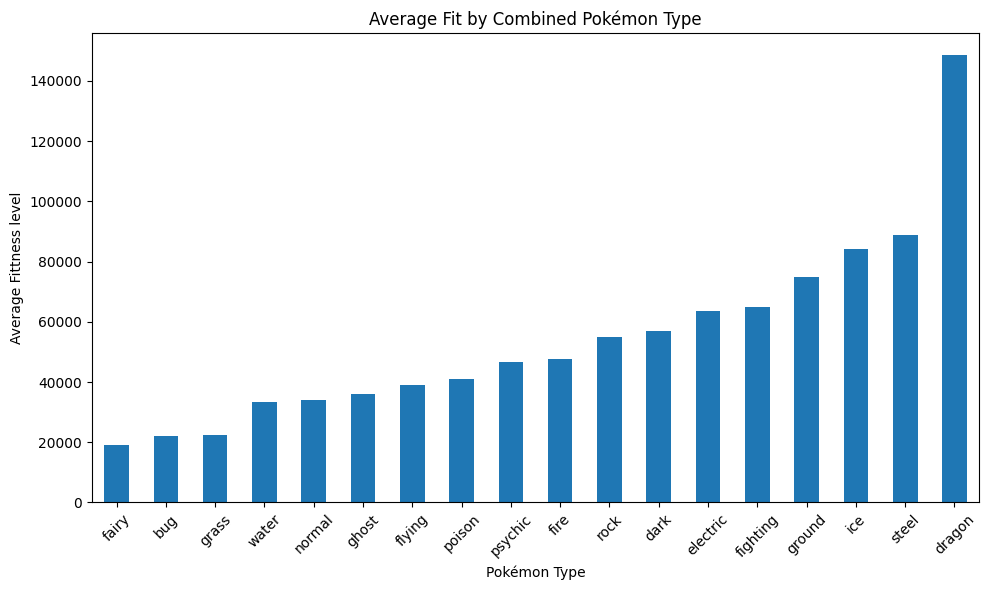

In [ ]:
average_fitness_type1 = pk.groupby('type1')['fit'].mean()
average_fitness_type2 = pk.groupby('type2')['fit'].mean()

average_fit = pd.DataFrame({
    'type1_fit': average_fitness_type1,
    'type2_fit': average_fitness_type2
})

average_fit['average_fitness'] = (average_fit['type1_fit'] + average_fit['type2_fit']) / 2

sorted_combined_average_fit = average_fit['average_fitness'].sort_values()

plt.figure(figsize=(10, 6))
sorted_combined_average_fit.plot(kind='bar')
plt.title('Average Fit by Combined Pokémon Type')
plt.xlabel('Pokémon Type')
plt.ylabel('Average Fittness level')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Finding the Top Ten Pokemons that went to the gym the hardest over the course of their life!

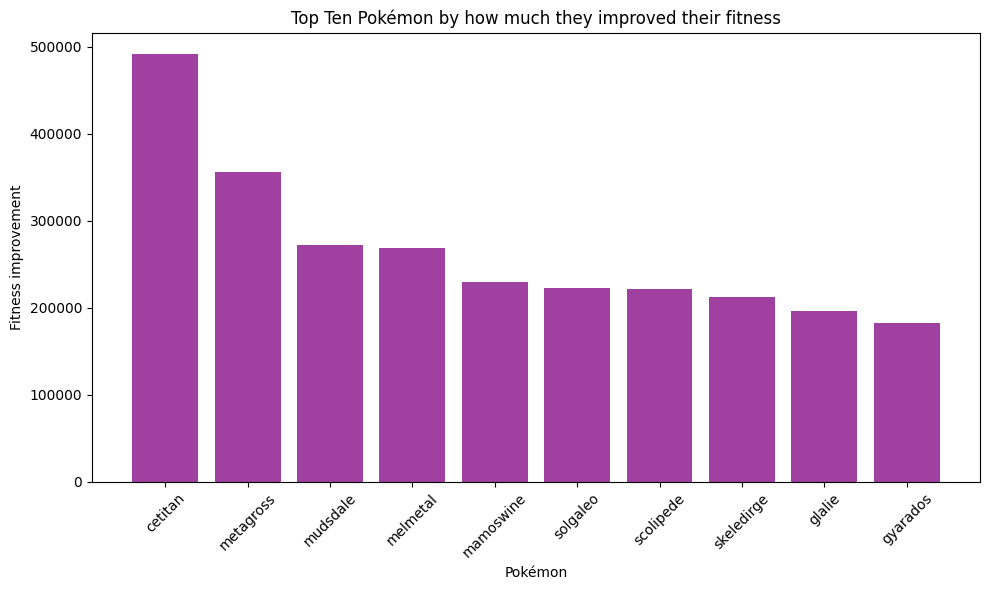

In [ ]:
def find_evolutions(df):
    basic_evolution = {}
    final_evolution = {}

    evolution_map = {row['name']: row['evolves_from'] for index, row in df.iterrows()}

    for pokemon in evolution_map:
        current = pokemon
        while evolution_map[current] != 'nothing':
            current = evolution_map[current]
        basic_evolution[pokemon] = current

        current = pokemon
        while current in evolution_map:
            next_evolution = [p for p, prev in evolution_map.items() if prev == current]
            if not next_evolution:
                break
            current = next_evolution[0]
        final_evolution[pokemon] = current

    return basic_evolution, final_evolution

basic_evo, final_evo = find_evolutions(pk)

pk['basic_evolution'] = pk['name'].map(basic_evo)
pk['final_evolution'] = pk['name'].map(final_evo)

def calculate_fit_difference(row):
    basic_fit = pk.loc[pk['name'] == row['basic_evolution'], 'fit'].values[0]
    final_fit = pk.loc[pk['name'] == row['final_evolution'], 'fit'].values[0]
    return final_fit - basic_fit

pk['fit_difference'] = pk.apply(calculate_fit_difference, axis=1)

df_unique = pk.loc[pk.groupby('final_evolution')['fit_difference'].idxmax()]

top_ten = df_unique.nlargest(10, 'fit_difference')

plt.figure(figsize=(10, 6))
plt.bar(top_ten['final_evolution'], top_ten['fit_difference'], color='#A040A0')
plt.title('Top Ten Pokémon by how much they improved their fitness')
plt.xlabel('Pokémon')
plt.ylabel('Fitness improvement')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Visualizing Correlation between Fitness and Fitness Improvement Level:

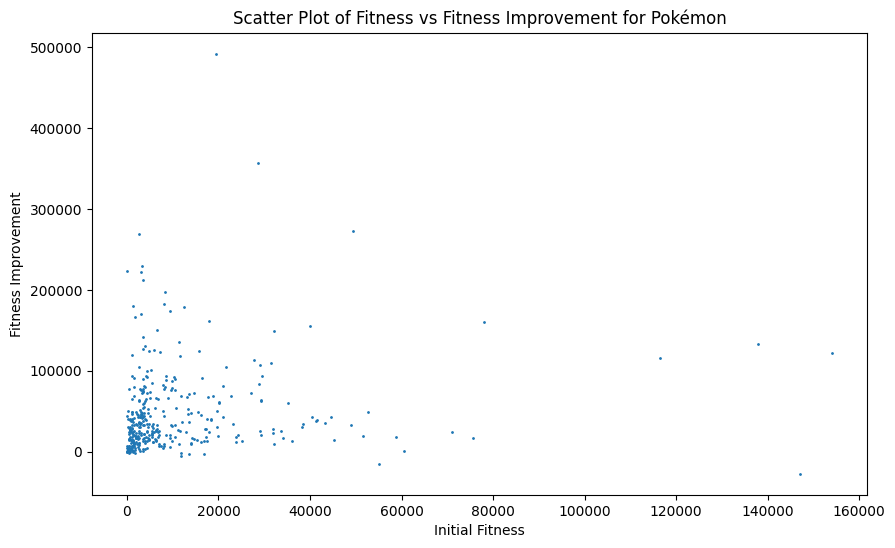

In [ ]:
pk_filtered = pk[pk['final_evolution'] != pk['basic_evolution']]
unique_pk = pk_filtered.drop_duplicates(subset='final_evolution')

plt.figure(figsize=(10, 6))

plt.scatter(unique_pk['fit'], unique_pk['fit_difference'], s=1)

plt.title('Scatter Plot of Fitness vs Fitness Improvement for Pokémon')
plt.xlabel('Initial Fitness')
plt.ylabel('Fitness Improvement')
plt.show()


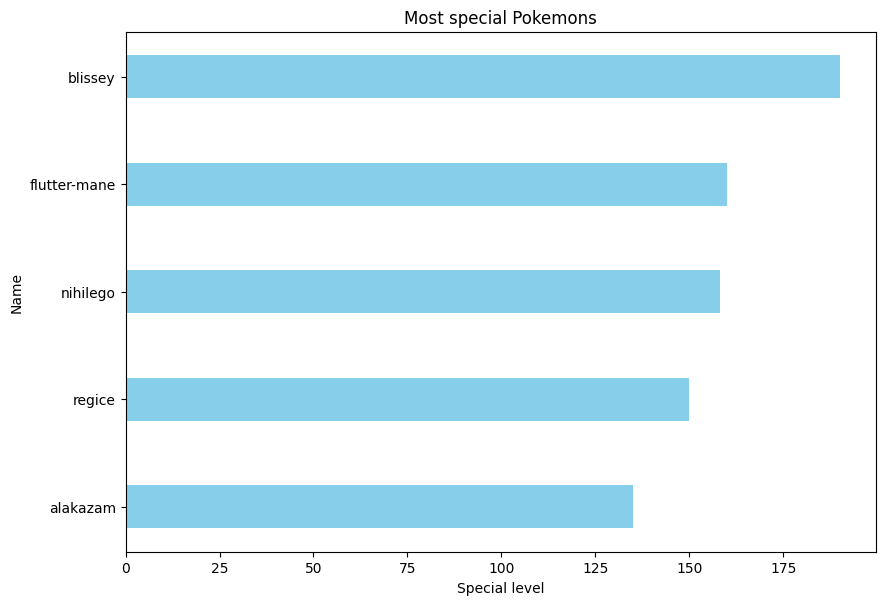

In [ ]:
#Adding a column that shows how special the pokemon is.
for index, row in pk.iterrows():
    pk['special'] = pk['spatk']+pk['spdef']-pk['atk']-pk['def']


most_special = pk.nlargest(5, 'special')

plt.figure(figsize=(10, 8))
plt.barh(most_special['name'], most_special['special'], color='skyblue', height=0.4)

plt.subplots_adjust(left=0.2, right=0.95, top=0.7, bottom=0.05)

plt.xlabel('Special level')
plt.ylabel('Name')
plt.title('Most special Pokemons')
plt.gca().invert_yaxis()
plt.show()

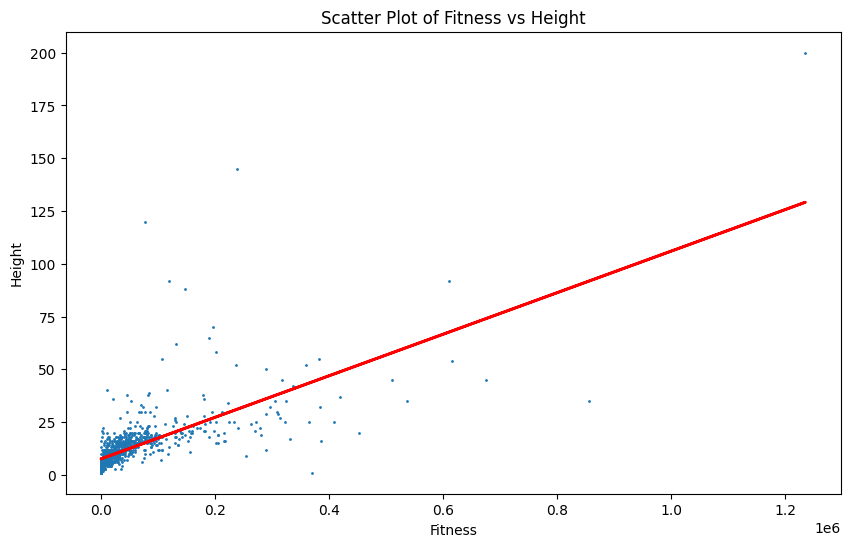

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(pk['fit'], pk['height'], s=1)

slope, intercept = np.polyfit(pk['fit'], pk['height'], 1)
regression_line = slope * pk['fit'] + intercept


plt.plot(pk['fit'], regression_line, color='red', linewidth=2)

plt.title('Scatter Plot of Fitness vs Height')
plt.xlabel('Fitness')
plt.ylabel('Height')
plt.show()


In [ ]:
rarity_mapping = {
    'baby': 1,
    'ordinary': 2,
    'legendary': 3,
    'mythical': 4
}

pk['rarity'] = pk['rank'].map(rarity_mapping)

#Special, fit to attack scatter, fit to defense scatter, fit to hp scatter, attack to total scatter. Only top evolved species. How does fit increase from weak evolved?

In [ ]:
pk = pk.drop(columns=['id', 'generation', 'name',
       'evolves_from', 'abilities', 'desc', 'type1', 'type2', 'rank', 'basic_evolution', 'final_evolution'])
pk.corr()

,hp,atk,def,spatk,spdef,speed,total,height,weight,fit,fit_difference,special
hp,1.000000,0.476141,0.299013,0.359616,0.369087,0.179877,0.667127,0.482714,0.476490,0.465830,0.035669,-0.045169
atk,0.476141,1.000000,0.465565,0.281880,0.226126,0.351055,0.714396,0.383843,0.402300,0.412506,0.049150,-0.537460
def,0.299013,0.465565,1.000000,0.210107,0.503281,0.008047,0.629466,0.347968,0.446933,0.365054,-0.011583,-0.435287
spatk,0.359616,0.281880,0.210107,1.000000,0.493034,0.423150,0.701154,0.318759,0.184609,0.284484,-0.153716,0.522843
spdef,0.369087,0.226126,0.503281,0.493034,1.000000,0.214105,0.697998,0.275874,0.264456,0.281582,-0.150582,0.366304
speed,0.179877,0.351055,0.008047,0.423150,0.214105,1.000000,0.553797,0.201195,0.042833,0.277336,-0.127870,0.139996
total,0.667127,0.714396,0.629466,0.701154,0.697998,0.553797,1.000000,0.505971,0.456771,0.525714,-0.090165,-0.005968
height,0.482714,0.383843,0.347968,0.318759,0.275874,0.201195,0.505971,1.000000,0.632440,0.696596,0.061200,-0.089222
weight,0.476490,0.402300,0.446933,0.184609,0.264456,0.042833,0.456771,0.632440,1.000000,0.872454,0.227940,-0.232335
fit,0.465830,0.412506,0.365054,0.284484,0.281582,0.277336,0.525714,0.696596,0.872454,1.000000,0.126011,-0.130291
